# Analise Exploratoria - Scopus UFRPE

Exploracao das metricas Scopus coletadas para os docentes da UFRPE
(`data/raw/scopus/scopus_ufrpe_reviewed.csv`).

**Disciplina**: Gestao da Informacao e do Conhecimento - UFRPE

## Objetivos

1. Sumarizar a qualidade do matching CAPES -> Scopus
2. Visualizar distribuicoes de citacoes, h-index e document_count
3. Identificar top docentes por impacto cientifico
4. Investigar relacao entre numero de documentos e citacoes
5. Validar a triagem (auto_triage + revisao manual)

## Dependencias

```bash
pip install pandas numpy matplotlib seaborn jupyter
```


## 1. Setup

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

# Caminho relativo a partir de scripts/ (ajustar se rodar em Colab)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "scripts" else Path.cwd()
SCOPUS_CSV = PROJECT_ROOT / "data" / "raw" / "scopus" / "scopus_ufrpe_reviewed.csv"
SCOPUS_RAW = PROJECT_ROOT / "data" / "raw" / "scopus" / "scopus_ufrpe.csv"
DOCENTES_CSV = PROJECT_ROOT / "data" / "processed" / "docentes_ufrpe.csv"

# Usa o CSV revisado se disponivel; senao, o cru
csv_path = SCOPUS_CSV if SCOPUS_CSV.exists() else SCOPUS_RAW
print(f"Lendo: {csv_path}")
df = pd.read_csv(csv_path)
print(f"Linhas: {len(df)}, Colunas: {len(df.columns)}")


Lendo: /home/gerorsch/Documents/project/gic/data/raw/scopus/scopus_ufrpe_reviewed.csv
Linhas: 826, Colunas: 12


## 2. Schema e qualidade

Inspecao das colunas, tipos e valores nulos.


In [2]:
# Schema completo
info = pd.DataFrame({
    "tipo": df.dtypes,
    "nulos": df.isnull().sum(),
    "%_nulos": (df.isnull().mean() * 100).round(1),
    "unicos": df.nunique(),
})
info


,tipo,nulos,%_nulos,unicos
author_name,str,0,0.0,826
citation_count,float64,12,1.5,411
h_index,float64,12,1.5,42
document_count,float64,12,1.5,135
scopus_author_id,float64,12,1.5,748
scopus_indexed_name,float64,826,100.0,0
scopus_affiliation_name,str,13,1.6,50
match_status,str,0,0.0,2
match_score,float64,12,1.5,104
query_used,str,0,0.0,754


In [3]:
df.head(3)

,author_name,citation_count,h_index,document_count,scopus_author_id,scopus_indexed_name,scopus_affiliation_name,match_status,match_score,query_used,error_message,review_status
0,ALEXANDRO CARDOSO TENORIO,53.0,2.0,2.0,5.719195e+10,NaN,Universidade Federal Rural de Pernambuco,matched,114.0,[last-only+afid] AUTHLAST(TENORIO) AND AF-ID(6...,NaN,accepted
1,REZILDA RODRIGUES OLIVEIRA,0.0,0.0,3.0,5.719172e+10,NaN,Universidade Federal Rural de Pernambuco,matched,130.0,AUTHLAST(OLIVEIRA) AND AUTHFIRST(REZILDA) AND ...,NaN,accepted
2,ALEXANDRE MENDES FERNANDES,818.0,14.0,28.0,3.556039e+10,NaN,Universidade Federal Rural de Pernambuco,matched,131.0,AUTHLAST(FERNANDES) AND AUTHFIRST(ALEXANDRE) A...,NaN,accepted


## 3. Status do matching

Distribuicao de `match_status` (matched / not_found / api_error).


match_status
matched      814
not_found     12


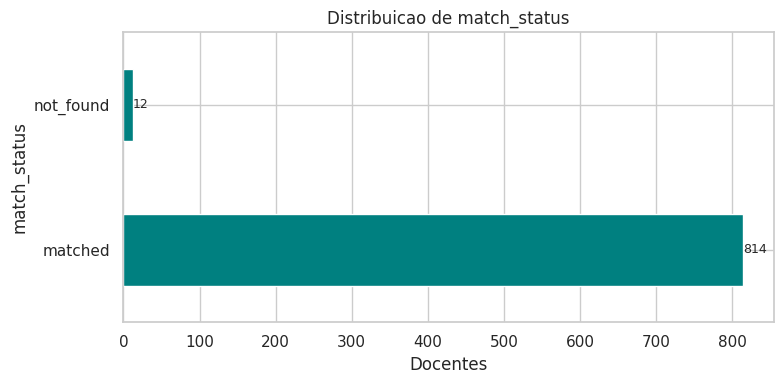


Taxa de match: 98.5%


In [4]:
status_counts = df["match_status"].value_counts(dropna=False)
print(status_counts.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
status_counts.plot(kind="barh", ax=ax, color="teal", edgecolor="white")
ax.set_title("Distribuicao de match_status")
ax.set_xlabel("Docentes")
for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}",
                (p.get_width(), p.get_y() + p.get_height()/2),
                ha="left", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nTaxa de match: {(df['match_status']=='matched').mean()*100:.1f}%")


## 4. Distribuicao do match_score

A formula em `gic_main.py` atribui pontos por similaridade do nome (ate 40),
nome (+20), sobrenome (+30), afiliacao UFRPE (+60) e bonus por documento (ate 5).
**Maximo teorico: 155**. Score >= 100 garante afiliacao UFRPE algoritmicamente
(o teto sem o bonus de afiliacao eh 95).


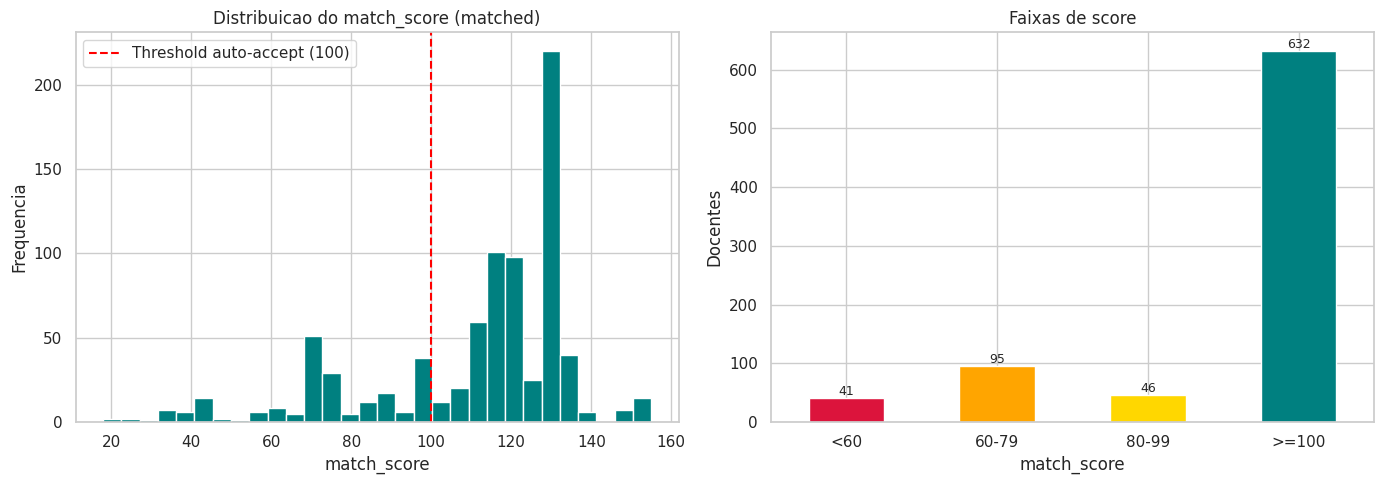

In [5]:
matched = df[df["match_status"] == "matched"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(matched["match_score"], bins=30, color="teal", edgecolor="white")
axes[0].axvline(100, color="red", linestyle="--", label="Threshold auto-accept (100)")
axes[0].set_title("Distribuicao do match_score (matched)")
axes[0].set_xlabel("match_score")
axes[0].set_ylabel("Frequencia")
axes[0].legend()

# Faixas de score
faixas = pd.cut(matched["match_score"],
                bins=[0, 59, 79, 99, 200],
                labels=["<60", "60-79", "80-99", ">=100"])
faixas.value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color=["crimson", "orange", "gold", "teal"],
    edgecolor="white"
)
axes[1].set_title("Faixas de score")
axes[1].set_ylabel("Docentes")
axes[1].tick_params(axis="x", rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height())}",
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


## 5. Score x afiliacao UFRPE

Cruzamento que motiva a regra do `auto_triage`: scores baixos com afiliacao
nao-UFRPE sao auto-rejeitados.


aff_ufrpe    Aff UFRPE  Aff outra
match_score                      
<60                 21         20
60-79               56         39
80-99               41          5
>=100              632          0


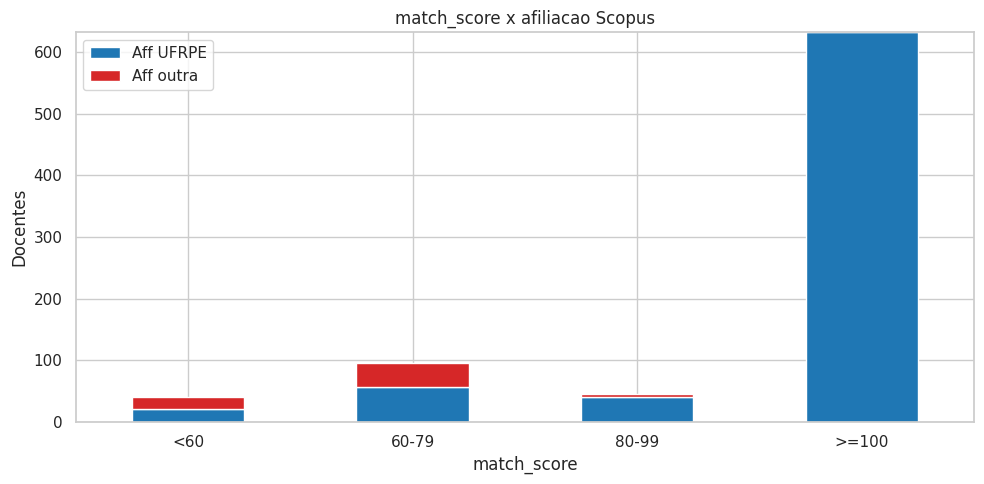

In [6]:
matched["aff_ufrpe"] = (
    matched["scopus_affiliation_name"].fillna("").str.upper()
    .str.contains("PERNAMBUCO|UFRPE", regex=True)
)

cross = pd.crosstab(
    pd.cut(matched["match_score"], bins=[0, 59, 79, 99, 200],
           labels=["<60", "60-79", "80-99", ">=100"]),
    matched["aff_ufrpe"].map({True: "Aff UFRPE", False: "Aff outra"})
)
print(cross)

fig, ax = plt.subplots(figsize=(10, 5))
cross.plot(kind="bar", stacked=True, ax=ax,
           color=["#1f77b4", "#d62728"], edgecolor="white")
ax.set_title("match_score x afiliacao Scopus")
ax.set_ylabel("Docentes")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="")
plt.tight_layout()
plt.show()


## 6. Distribuicoes das metricas

`citation_count`, `h_index` e `document_count` sao distribuicoes
heavy-tailed - usar log-scale.


In [7]:
metricas = ["citation_count", "h_index", "document_count"]
print(matched[metricas].describe().round(2))


       citation_count  h_index  document_count
count          814.00   814.00          814.00
mean           549.48     8.34           33.22
std           1330.18     8.95           48.30
min              0.00     0.00            1.00
25%             10.00     1.00            2.00
50%            117.00     5.00           13.00
75%            633.50    13.00           45.00
max          24704.00    71.00          435.00


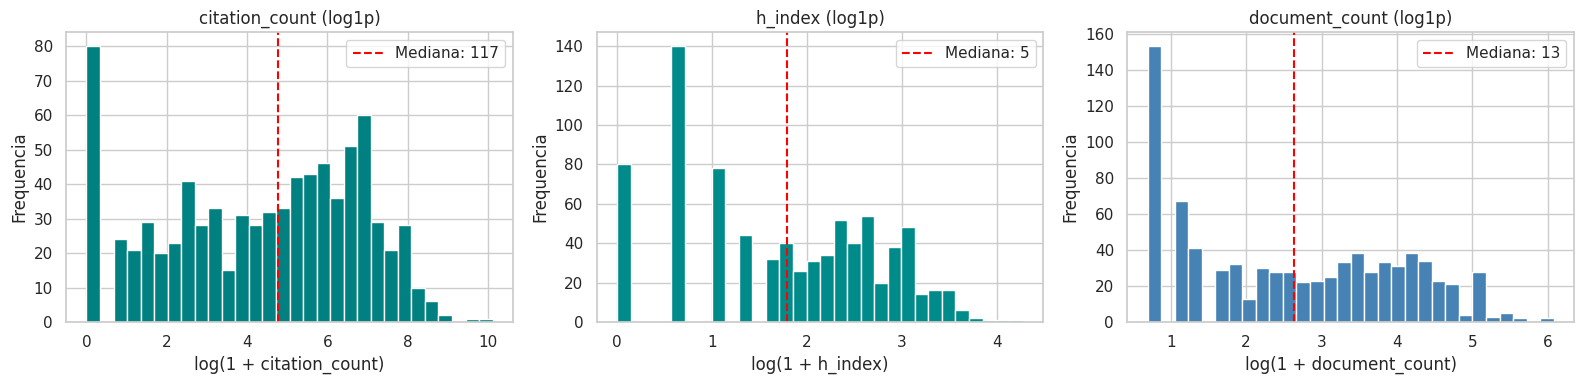

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, color in zip(axes, metricas, ["teal", "darkcyan", "steelblue"]):
    data = matched[col].dropna()
    # log1p para lidar com zeros
    ax.hist(np.log1p(data), bins=30, color=color, edgecolor="white")
    ax.set_title(f"{col} (log1p)")
    ax.set_xlabel(f"log(1 + {col})")
    ax.set_ylabel("Frequencia")
    ax.axvline(np.log1p(data.median()), color="red", linestyle="--",
               label=f"Mediana: {data.median():.0f}")
    ax.legend()

plt.tight_layout()
plt.show()


## 7. Top docentes por impacto cientifico

Os 20 mais citados e os 20 com maior h-index entre os matched.


In [9]:
top_cites = (matched.sort_values("citation_count", ascending=False)
             .head(20)[["author_name", "citation_count", "h_index", "document_count"]]
             .reset_index(drop=True))
top_cites.index += 1
top_cites


,author_name,citation_count,h_index,document_count
1,LUIZ ANTONIO MARTINELLI,24704.0,71.0,283.0
2,ULYSSES PAULINO DE ALBUQUERQUE,13610.0,60.0,435.0
3,RENATA VALERIANO TONON,7413.0,39.0,102.0
4,SOPHIE ANNICK NATHALIE LANCO BERTRAND,7315.0,50.0,166.0
5,JACKSON ROBERTO GUEDES DA SILVA ALMEIDA,6036.0,38.0,252.0
6,ARNAUD PIERRE ALEXIS BERTRAND,5300.0,44.0,160.0
7,GALBA MARIA DE CAMPOS TAKAKI,5257.0,42.0,154.0
8,EVERARDO VALADARES DE SA BARRETO SAMPAIO,5256.0,38.0,156.0
9,SILVIO CESAR SAMPAIO,5256.0,38.0,156.0
10,ANA LUCIA FIGUEIREDO PORTO,5119.0,36.0,254.0


In [10]:
top_h = (matched.sort_values("h_index", ascending=False)
         .head(20)[["author_name", "citation_count", "h_index", "document_count"]]
         .reset_index(drop=True))
top_h.index += 1
top_h


,author_name,citation_count,h_index,document_count
1,LUIZ ANTONIO MARTINELLI,24704.0,71.0,283.0
2,ULYSSES PAULINO DE ALBUQUERQUE,13610.0,60.0,435.0
3,SOPHIE ANNICK NATHALIE LANCO BERTRAND,7315.0,50.0,166.0
4,ARNAUD PIERRE ALEXIS BERTRAND,5300.0,44.0,160.0
5,GALBA MARIA DE CAMPOS TAKAKI,5257.0,42.0,154.0
6,RENATA VALERIANO TONON,7413.0,39.0,102.0
7,EVERARDO VALADARES DE SA BARRETO SAMPAIO,5256.0,38.0,156.0
8,JACKSON ROBERTO GUEDES DA SILVA ALMEIDA,6036.0,38.0,252.0
9,SILVIO CESAR SAMPAIO,5256.0,38.0,156.0
10,LINDOMAR JOSE PENA,3150.0,37.0,169.0


## 8. Correlacao entre metricas

Espera-se forte correlacao positiva entre `citation_count`, `h_index` e
`document_count` (mais artigos -> mais citacoes -> maior h-index).


Correlacao de Spearman:
                citation_count  h_index  document_count
citation_count           1.000    0.978           0.929
h_index                  0.978    1.000           0.950
document_count           0.929    0.950           1.000


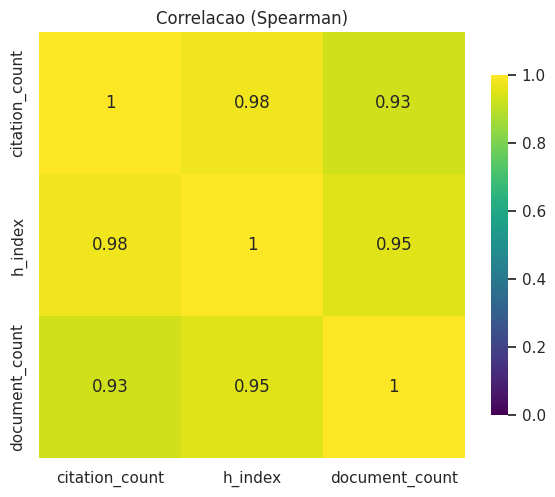

In [11]:
corr = matched[metricas].corr(method="spearman")
print("Correlacao de Spearman:")
print(corr.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="viridis", vmin=0, vmax=1,
            square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Correlacao (Spearman)")
plt.tight_layout()
plt.show()


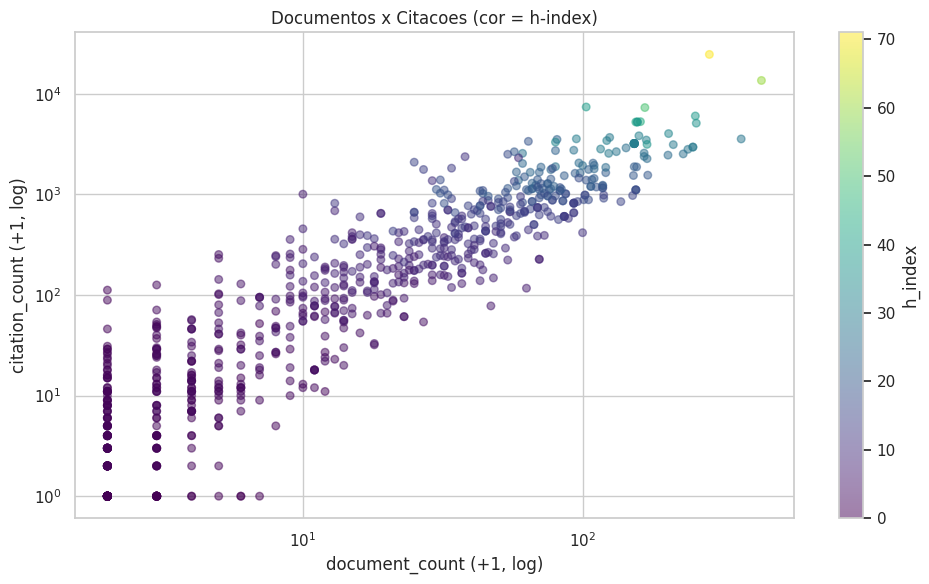

In [12]:
# Scatter: documentos x citacoes (log-log)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(matched["document_count"] + 1, matched["citation_count"] + 1,
           alpha=0.5, s=30, c=matched["h_index"], cmap="viridis")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("document_count (+1, log)")
ax.set_ylabel("citation_count (+1, log)")
ax.set_title("Documentos x Citacoes (cor = h-index)")
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label("h_index")
plt.tight_layout()
plt.show()


## 9. Afiliacoes Scopus

Top 10 afiliacoes presentes nos matched. Esperamos predominancia da UFRPE,
mas alguns docentes aparecem afiliados a instituicoes onde fizeram pos-doc
ou estao em colaboracao.


scopus_affiliation_name
Universidade Federal Rural de Pernambuco                  674
Universidade Federal de Pernambuco                         39
Universidade Federal do Agreste de Pernambuco              27
Fundacao Universidade Federal do Vale do Sao Francisco      7
Universidade de Pernambuco                                  6
Universidade Federal Rural do Semi-Árido                    4
Universidade Federal da Paraíba                             4
Universidade Federal de Campina Grande                      3
Universidade Catolica de Pernambuco                         2
Empresa Brasileira de Pesquisa Agropecuária - Embrapa       2


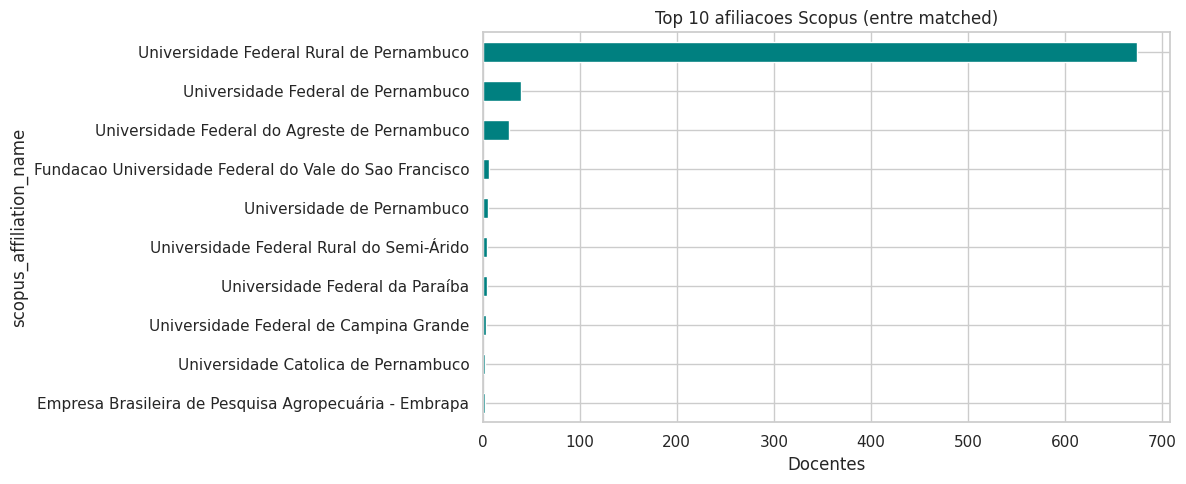

In [13]:
top_affil = (matched["scopus_affiliation_name"]
             .fillna("(sem afiliacao)")
             .value_counts()
             .head(10))
print(top_affil.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
top_affil.iloc[::-1].plot(kind="barh", ax=ax, color="teal", edgecolor="white")
ax.set_title("Top 10 afiliacoes Scopus (entre matched)")
ax.set_xlabel("Docentes")
plt.tight_layout()
plt.show()


## 10. Validacao: review_status

Distribuicao apos a triagem automatica + revisao manual.


review_status
accepted      726
rejected       88
(pendente)     12


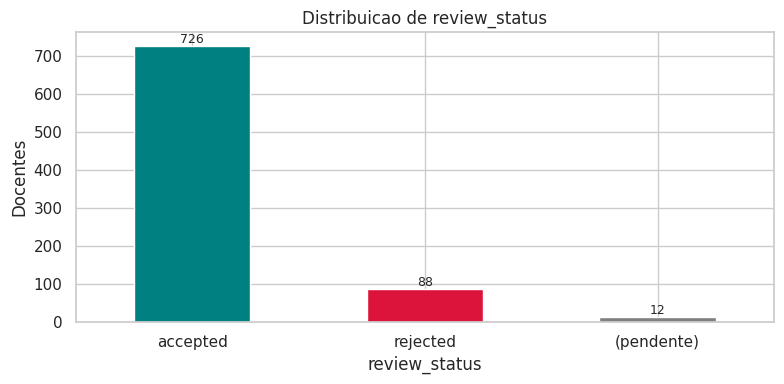

In [14]:
if "review_status" not in df.columns:
    print("Coluna review_status ausente - rode auto_triage.py primeiro.")
else:
    rs = df["review_status"].fillna("(pendente)").value_counts()
    print(rs.to_string())

    fig, ax = plt.subplots(figsize=(8, 4))
    rs.plot(kind="bar", ax=ax, color=["teal", "crimson", "gray"],
            edgecolor="white")
    ax.set_title("Distribuicao de review_status")
    ax.set_ylabel("Docentes")
    ax.tick_params(axis="x", rotation=0)
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height())}",
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()


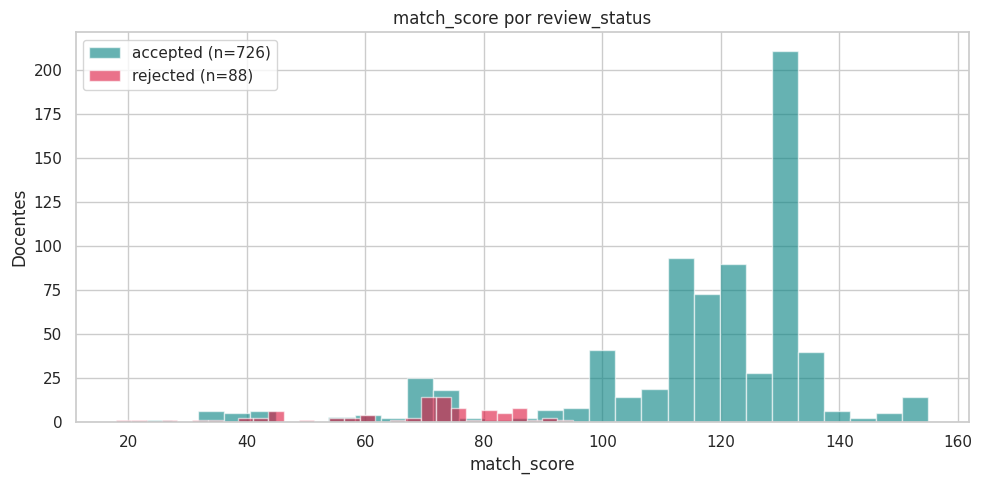

In [15]:
# review_status x match_score
if "review_status" in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    for status, color in [("accepted", "teal"), ("rejected", "crimson")]:
        sub = matched[matched["review_status"] == status]["match_score"]
        if len(sub) > 0:
            ax.hist(sub, bins=30, alpha=0.6, label=f"{status} (n={len(sub)})",
                    color=color, edgecolor="white")
    ax.set_xlabel("match_score")
    ax.set_ylabel("Docentes")
    ax.set_title("match_score por review_status")
    ax.legend()
    plt.tight_layout()
    plt.show()


## 11. Quem ficou de fora (not_found)

Lista dos docentes para os quais nao foi possivel encontrar perfil Scopus,
mesmo apos `recover_not_found.py`.


In [16]:
not_found = df[df["match_status"] == "not_found"][["author_name", "query_used"]]
print(f"Total not_found: {len(not_found)}\n")
not_found.reset_index(drop=True)


Total not_found: 12



,author_name,query_used
0,PAULA BRAGA GOMES DE PEREZ,AUTHLAST(PEREZ) AND AUTHFIRST(PAULA) AND AFFIL...
1,ALBERT STEVENS REYNA OCAS,AUTHLAST(OCAS) AND AUTHFIRST(ALBERT) AND AFFIL...
2,JULIA FIGUEREDO BENZAQUEN,AUTHLAST(BENZAQUEN) AND AUTHFIRST(JULIA) AND A...
3,MARIA CELIA PEREIRA LIMA HERNANDES,AUTHLAST(HERNANDES) AND AUTHFIRST(MARIA) AND A...
4,EDUARDO BARBUIO,AUTHLAST(BARBUIO) AND AUTHFIRST(EDUARDO) AND A...
5,GIUSEPPA MARIA DANIEL SPENILLO,AUTHLAST(SPENILLO) AND AUTHFIRST(GIUSEPPA) AND...
6,KARLA FERREIRA DE ARRUDA DUQUE,AUTHLAST(DUQUE) AND AUTHFIRST(KARLA) AND AFFIL...
7,PETRONIO JOSE DE LIMA MARTELLI,AUTHLAST(MARTELLI) AND AUTHFIRST(PETRONIO) AND...
8,MARLENE MARIA OGLIARI,AUTHLAST(OGLIARI) AND AUTHFIRST(MARLENE) AND A...
9,VALDIR DE QUEIROZ BALBINO,AUTHLAST(BALBINO) AND AUTHFIRST(VALDIR) AND AF...


## 12. Cruzamento com CAPES

Quanto da nossa base CAPES tem metricas Scopus aproveitaveis (matched + accepted)?


In [17]:
if DOCENTES_CSV.exists():
    docentes = pd.read_csv(DOCENTES_CSV, sep=";", encoding="utf-8-sig")
    print(f"Docentes UFRPE (CAPES): {len(docentes)}")

    matched_aceitos = df[
        (df["match_status"] == "matched") &
        (df.get("review_status", pd.Series([None]*len(df))) == "accepted")
    ]
    print(f"Matched + accepted: {len(matched_aceitos)} "
          f"({len(matched_aceitos)/len(docentes)*100:.1f}%)")

    matched_total = df[df["match_status"] == "matched"]
    print(f"Matched (qualquer status): {len(matched_total)} "
          f"({len(matched_total)/len(docentes)*100:.1f}%)")
else:
    print(f"Arquivo nao encontrado: {DOCENTES_CSV}")
    print("Rode generate_oml_from_capes_docentes_ufrpe.py para gera-lo.")


Docentes UFRPE (CAPES): 826
Matched + accepted: 726 (87.9%)
Matched (qualquer status): 814 (98.5%)


## 13. Proximos passos

- [ ] Cruzar `accepted` com `AN_TITULACAO` (CAPES) para o estudo
      tempo-de-carreira x citacoes
- [ ] Investigar os 88 `rejected`: refazer query manual ou descartar do estudo
- [ ] Investigar os 12 `not_found`: docentes podem nao ter perfil Scopus
- [ ] Regenerar o OML final usando apenas docentes com `review_status='accepted'`
